<div style="background:linear-gradient(135deg,#0b3a5e 0%,#0e6a8f 55%,#22b6d6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#cdeefb;font-weight:700;text-transform:uppercase">Chapter 27 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Spotify Track Features 🎧</div>
  <div style="font-size:15px;color:#e4f5fc;max-width:720px;line-height:1.6">One messy file of 915 songs, taken from raw to analysis-ready. We audit, describe, visualize, then clean every problem in turn, explaining the reason for each decision.</div>
  <div style="margin-top:16px;font-size:13px;color:#d2eefa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; load
The data loads from the book's `data/` folder (local) with a GitHub raw-URL fallback (Colab).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
CYAN="#0891b2"; AMBER="#d97706"; PURPLE="#7c3aed"; GREEN="#059669"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
pd.set_option("display.max_columns", 30)

BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/spotify_tracks.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"spotify_tracks.csv")
raw_rows = len(df)
print("loaded:", df.shape)

loaded: (915, 13)


<div style="background:#e7f6fb;border-left:5px solid #0891b2;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#0891b2;letter-spacing:1px">BEAT 1 · FIRST CONTACT</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Audit before anything else</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Look at the raw file: shape, dtypes, duplicates, missingness, and how the categories were actually typed in. We fix nothing yet, we just find out what we are dealing with.</div>
</div>

In [2]:
print("shape:", df.shape)
print("\nduplicate rows:", int(df.duplicated().sum()))
miss = df.isna().sum(); print("\nmissing:\n", miss[miss>0].to_string())
print("\ngenre typed", df["genre"].nunique(), "ways:", sorted(df["genre"].dropna().unique()))
print("\nmode typed", df["mode"].nunique(), "ways:", sorted(df["mode"].dropna().unique()))
print("\ntempo == 0 (impossible):", int((df["tempo"]==0).sum()))
df.head(3)

shape: (915, 13)

duplicate rows: 8

missing:
 tempo         18
key           12
popularity    73

genre typed 19 ways: ['EDM', 'Electronic', 'Hip-Hop', 'POP', 'Pop', 'R&B', 'classical', 'country', 'electronic', 'hip hop', 'hip-hop', 'hiphop', 'jazz', 'pop', 'pop ', 'r and b', 'r&b', 'rnb', 'rock']

mode typed 8 ways: ['M', 'Maj', 'Major', 'Min', 'Minor', 'm', 'major', 'minor']

tempo == 0 (impossible): 23


,track_id,track_name,artist,genre,danceability,energy,loudness,tempo,valence,duration_ms,key,mode,popularity
0,TRK00063,Silent Summer,Foxglove,pop,0.890,0.707,-21.31,143.448,0.436,215091,0.0,Major,10.0
1,TRK00677,Velvet Gravity,The Paper Kites,rock,0.532,0.808,-16.58,117.839,0.274,280893,4.0,Major,20.0
2,TRK00140,Broken Waves,Northbound,r&b,0.722,0.368,-38.31,136.771,0.476,210682,7.0,Major,38.0


**What the audit reveals:** eight duplicate rows; missing `tempo`, `key`, and `popularity`; a `genre` column typed nineteen different ways for eight real genres; `mode` typed eight ways for two; and a `tempo` of 0 BPM, which is impossible and therefore missing data in disguise. That is the to-do list.

<div style="background:#e7f6fb;border-left:5px solid #0891b2;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#7c3aed;letter-spacing:1px">BEAT 2 · DESCRIBE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Numbers first</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Descriptive statistics on the numeric columns. The headline is the <b>scales</b>: these features live in completely different number ranges, which will matter the moment we model.</div>
</div>

In [3]:
num = ["danceability","energy","loudness","tempo","valence","duration_ms","popularity"]
desc = df[num].describe().loc[["mean","std","min","max"]].round(2)
print(desc.to_string())
print("\nNotice the ranges: danceability 0-1, loudness -40-0 dB, tempo 0-300,")
print("duration_ms in the hundreds of thousands. Four different worlds.")

      danceability  energy  loudness   tempo  valence  duration_ms  popularity
mean          0.56    0.56    -27.63  115.30     0.52    239581.64       28.67
std           0.19    0.22     10.32   32.68     0.21    595349.75       16.69
min           0.08    0.02    -40.00    0.00     0.01     97419.00        0.00
max           0.95    0.98     -0.25  299.00     1.00  18000000.00       81.00

Notice the ranges: danceability 0-1, loudness -40-0 dB, tempo 0-300,
duration_ms in the hundreds of thousands. Four different worlds.


<div style="background:#e7f6fb;border-left:5px solid #0891b2;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#d97706;letter-spacing:1px">BEAT 3 · VISUALIZE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Let the charts talk</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Three pictures: the distribution of <code>popularity</code>, a correlation heatmap of the audio features, and the one strong relationship it reveals. (We plot the raw data first, then re-plot after cleaning.)</div>
</div>

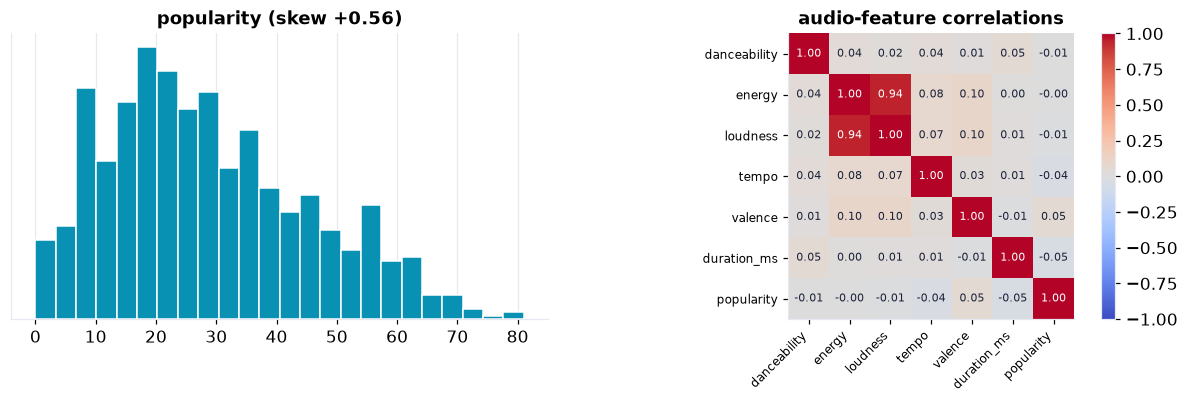

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].hist(df["popularity"].dropna(), bins=24, color=CYAN, edgecolor="white")
ax[0].set_title(f"popularity (skew {df['popularity'].skew():+.2f})"); ax[0].set_yticks([])
# correlation heatmap
corr = df[num].corr()
im = ax[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(num))); ax[1].set_xticklabels(num, rotation=45, ha="right", fontsize=8)
ax[1].set_yticks(range(len(num))); ax[1].set_yticklabels(num, fontsize=8)
for i in range(len(num)):
    for j in range(len(num)):
        ax[1].text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7,
                   color="white" if abs(corr.iloc[i,j])>0.6 else "#1a2138")
ax[1].set_title("audio-feature correlations"); ax[1].grid(False)
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

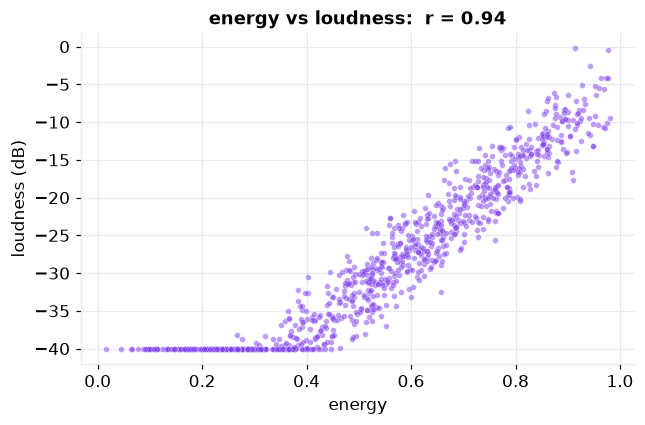

energy and loudness move together almost perfectly (r = 0.94).


In [5]:
r = df["energy"].corr(df["loudness"])
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df["energy"], df["loudness"], s=14, color=PURPLE, alpha=0.5, edgecolor="white", linewidth=0.3)
ax.set_xlabel("energy"); ax.set_ylabel("loudness (dB)")
ax.set_title(f"energy vs loudness:  r = {r:.2f}"); plt.tight_layout(); plt.show()
print(f"energy and loudness move together almost perfectly (r = {r:.2f}).")

**What the visuals say:** `popularity` is mildly right-skewed; almost every audio feature is uncorrelated with every other, with one loud exception, **energy and loudness correlate at r ≈ 0.94**. That near-duplication is *multicollinearity*: the two columns carry nearly the same information. Worth knowing now, because we may later drop or combine one of them.

<div style="background:#e7f6fb;border-left:5px solid #0891b2;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">BEAT 4 · CLEAN</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Duplicates, categories, missing values</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Now we fix what the audit found, in order. <b>Deduplicate</b> (Ch 19), <b>standardise the categories</b> (Ch 19), then <b>handle the missing values</b> (Ch 20), each with its reason.</div>
</div>

In [6]:
clean = df.drop_duplicates().copy()
print(f"deduplicate: {raw_rows} -> {len(clean)} rows  ({raw_rows-len(clean)} exact duplicates removed)")

# standardise genre (19 spellings -> 8) and mode (8 -> 2)
gmap = {"pop":"pop","Pop":"pop","POP":"pop","pop ":"pop",
        "hip-hop":"hip-hop","hip hop":"hip-hop","Hip-Hop":"hip-hop","hiphop":"hip-hop",
        "r&b":"r&b","R&B":"r&b","rnb":"r&b","r and b":"r&b",
        "electronic":"electronic","Electronic":"electronic","EDM":"electronic"}
clean["genre"] = clean["genre"].str.strip().map(lambda g: gmap.get(g, g))
mmap = {"Major":"Major","major":"Major","M":"Major","Maj":"Major",
        "Minor":"Minor","minor":"Minor","m":"Minor","Min":"Minor"}
clean["mode"] = clean["mode"].map(lambda m: mmap.get(m, m))
print("genres now:", clean["genre"].nunique(), "| modes now:", sorted(clean["mode"].dropna().unique()))

deduplicate: 915 -> 907 rows  (8 exact duplicates removed)
genres now: 8 | modes now: ['Major', 'Minor']


In [7]:
# missing values, each treated on its merits
# 1) tempo: 0 is impossible -> recode to NaN, then median-impute (a measurement gap)
clean["tempo"] = clean["tempo"].replace(0, np.nan)
tempo_med = clean["tempo"].median()
n_tempo = int(clean["tempo"].isna().sum())
clean["tempo"] = clean["tempo"].fillna(tempo_med)
# 2) key: nominal (musical key) -> impute the mode
clean["key"] = clean["key"].fillna(clean["key"].mode()[0])
# 3) popularity is the OUTCOME we care about -> do not invent it; drop those rows
n_pop = int(clean["popularity"].isna().sum())
clean = clean.dropna(subset=["popularity"])
print(f"tempo: recoded 0->NaN and median-imputed {n_tempo} values (median {tempo_med:.1f})")
print(f"key:   mode-imputed the missing musical keys")
print(f"popularity: dropped {n_pop} rows missing the outcome (never impute a target)")
print("rows now:", len(clean))

tempo: recoded 0->NaN and median-imputed 41 values (median 117.6)
key:   mode-imputed the missing musical keys
popularity: dropped 73 rows missing the outcome (never impute a target)
rows now: 834


**Why these three differ:** a missing `tempo` is a measurement gap, so we estimate it (median, which resists outliers). A missing `key` is a category, so we fill the most common one. But `popularity` is the thing we ultimately want to explain, and inventing values for your outcome biases everything downstream, so those rows are dropped instead. Same problem, three different right answers (Chapter 20).

<div style="background:#e7f6fb;border-left:5px solid #0891b2;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#db2777;letter-spacing:1px">BEAT 5 · OUTLIERS</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Find the impossible durations</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">A box plot of <code>duration_ms</code> screams: a handful of tracks are minutes, even hours, too long. We separate genuine long songs from data errors and remove only the errors (Ch 21).</div>
</div>

IQR upper fence: 6.3 min;  rows above it: 19
impossible durations (minutes): [300.0, 25.0, 32.0]


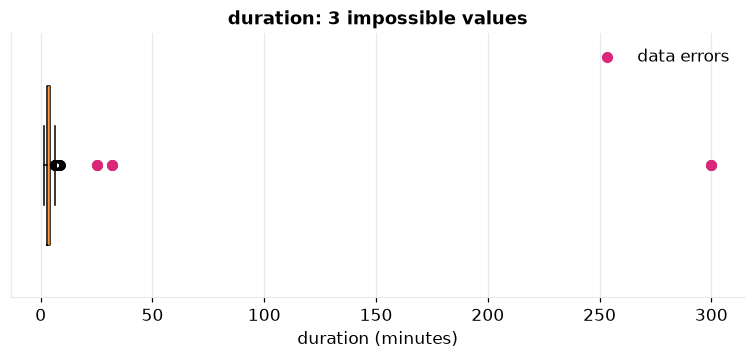

removed 3 corrupt rows; 831 remain


In [8]:
dur_min = clean["duration_ms"]/60000
q1,q3 = clean["duration_ms"].quantile([.25,.75]); iqr=q3-q1; fence=q3+1.5*iqr
print(f"IQR upper fence: {fence/60000:.1f} min;  rows above it: {int((clean['duration_ms']>fence).sum())}")
errors = clean[clean["duration_ms"]>600000]   # > 10 minutes = almost certainly corrupt
print("impossible durations (minutes):", (errors["duration_ms"]/60000).round(1).to_list())

fig, ax = plt.subplots(figsize=(7,3.4))
ax.boxplot(dur_min, orientation="horizontal", widths=0.6)
ax.scatter(errors["duration_ms"]/60000, [1]*len(errors), color=PINK, zorder=5, s=40, label="data errors")
ax.set_xlabel("duration (minutes)"); ax.set_title("duration: 3 impossible values"); ax.legend()
ax.set_yticks([]); plt.tight_layout(); plt.show()

before = len(clean); clean = clean[clean["duration_ms"]<=600000].copy()
print(f"removed {before-len(clean)} corrupt rows; {len(clean)} remain")

**Remove vs keep:** the IQR rule flags a couple dozen long tracks, but most are legitimate (extended mixes, classical pieces). Only three are *impossible*, up to five hours, so those are the data errors we delete. We keep the genuine long songs: an outlier is not automatically an error, and judgment, not a blind rule, decides (Chapter 21).

<div style="background:#e7f6fb;border-left:5px solid #0891b2;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#7c3aed;letter-spacing:1px">BEAT 6 · TRANSFORM, SCALE &amp; ENCODE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Make it model-ready</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Two last shaping steps. A <b>log transform</b> straightens the skewed <code>duration</code> (Ch 22); <b>scaling</b> puts every feature on the same footing (Ch 24); and we <b>one-hot encode</b> genre so a model can use it (Ch 24).</div>
</div>

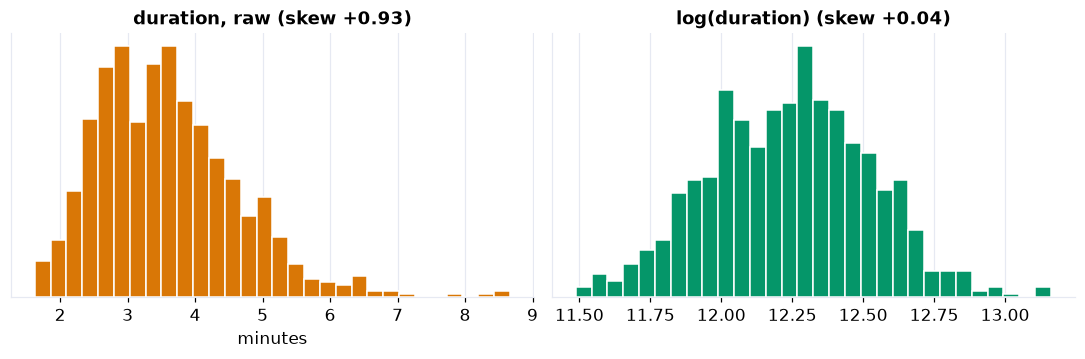

log transform pulled skew from +0.93 to +0.04: near-symmetric.


In [9]:
from sklearn.preprocessing import StandardScaler

# log transform the skewed duration
before_sk = clean["duration_ms"].skew()
clean["log_duration"] = np.log(clean["duration_ms"])
after_sk = clean["log_duration"].skew()
fig, ax = plt.subplots(1,2,figsize=(10,3.4))
ax[0].hist(clean["duration_ms"]/60000, bins=30, color=AMBER, edgecolor="white")
ax[0].set_title(f"duration, raw (skew {before_sk:+.2f})"); ax[0].set_xlabel("minutes"); ax[0].set_yticks([])
ax[1].hist(clean["log_duration"], bins=30, color=GREEN, edgecolor="white")
ax[1].set_title(f"log(duration) (skew {after_sk:+.2f})"); ax[1].set_yticks([])
plt.tight_layout(); plt.show()
print(f"log transform pulled skew from {before_sk:+.2f} to {after_sk:+.2f}: near-symmetric.")

In [10]:
# scale the audio features so none dominate by sheer magnitude
feat = ["danceability","energy","loudness","tempo","valence","log_duration"]
scaled = pd.DataFrame(StandardScaler().fit_transform(clean[feat]), columns=feat, index=clean.index)
print("BEFORE scaling (std of each feature):")
print(clean[feat].std().round(2).to_string())
print("\nAFTER standardising (every std = 1, every mean = 0):")
print(scaled.std().round(2).to_string())

# one-hot encode the (now clean) genre
genre_oh = pd.get_dummies(clean["genre"], prefix="genre")
print("\none-hot genre columns:", list(genre_oh.columns))

BEFORE scaling (std of each feature):
danceability     0.19
energy           0.22
loudness        10.35
tempo           26.73
valence          0.21
log_duration     0.29

AFTER standardising (every std = 1, every mean = 0):
danceability    1.0
energy          1.0
loudness        1.0
tempo           1.0
valence         1.0
log_duration    1.0

one-hot genre columns: ['genre_classical', 'genre_country', 'genre_electronic', 'genre_hip-hop', 'genre_jazz', 'genre_pop', 'genre_r&b', 'genre_rock']


In [11]:
# assemble the analysis-ready table
ready = pd.concat([scaled, clean[["popularity"]].reset_index(drop=True).set_index(scaled.index),
                   genre_oh], axis=1)
print("ANALYSIS-READY:", ready.shape)
print(f"\njourney: {raw_rows} raw rows  ->  {len(ready)} clean rows, {ready.shape[1]} model-ready columns")
ready.head(3)

ANALYSIS-READY: (831, 15)

journey: 915 raw rows  ->  831 clean rows, 15 model-ready columns


,danceability,energy,loudness,tempo,valence,log_duration,popularity,genre_classical,genre_country,genre_electronic,genre_hip-hop,genre_jazz,genre_pop,genre_r&b,genre_rock
0,1.728965,0.647654,0.601988,0.938509,-0.396648,0.128207,10.0,False,False,False,False,False,True,False,False
1,-0.135705,1.105685,1.059423,-0.020261,-1.165114,1.064286,20.0,False,False,False,False,False,False,False,True
2,0.853924,-0.889699,-1.042067,0.688530,-0.206904,0.055571,38.0,False,False,False,False,False,False,True,False


---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap: what we did and why</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Deduplicated</b> 8 exact-copy rows (Ch 19), they would double-count songs.</li>
<li><b>Standardised</b> genre (19 spellings → 8) and mode (8 → 2) so groups are real (Ch 19).</li>
<li><b>Recoded</b> tempo 0 → NaN and median-imputed; mode-imputed key; <b>dropped</b> rows missing the outcome <code>popularity</code> (Ch 20).</li>
<li><b>Removed</b> 3 impossible durations while keeping genuine long songs (Ch 21).</li>
<li><b>Log-transformed</b> the skewed duration, <b>scaled</b> all features, and <b>one-hot encoded</b> genre (Ch 22 &amp; 24).</li>
</ul>
<div style="color:#4a5578;line-height:1.7;margin-top:6px">Along the way the data told us something: <b>energy and loudness are near-duplicates (r ≈ 0.94)</b>, and audio features barely predict popularity here. That is a finding, not a cleaning step, and it is exactly what exploratory analysis is for.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>